# Maximal Lottery Sampled Winner: Expected Distortion

In [31]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

sys.path.insert(0, '/home/jennifer/distortion')
from utils_3 import (
    maximal_lotteries_from_population_utilities,
    argmax_lottery_from_population_utilities,
    nonzero_max_from_population_utilities,
    leaderboard_dist,
)

## Synthetic population

Sample utilities for N voters and M candidates from a standard normal. Voters are weighted uniformly.

In [3]:
M = 10  # candidates
N = 10  # voters
beta = 1.0
rng = np.random.default_rng(42)

utilities = rng.standard_normal((N, M))
voter_dist = np.ones(N, dtype=float) / N

avg_utilities = voter_dist @ utilities
true_ranking = np.argsort(-avg_utilities)

print("avg_utilities:", np.round(avg_utilities, 3))
print("true ranking (best to worst):", true_ranking)

avg_utilities: [ 0.234 -0.24  -0.214  0.163 -0.368 -0.128 -0.106 -0.132  0.263  0.025]
true ranking (best to worst): [8 0 3 9 6 5 7 2 1 4]


## Baseline helper functions

Reproduce Borda and Borda-peeling from the win-rate matrix (same as simulation_23).

In [4]:
def win_rate_matrix(utilities, voter_dist, beta=1.0):
    V, C = utilities.shape
    P = np.zeros((C, C), dtype=float)
    for v, u in enumerate(utilities):
        diffs = u[:, None] - u[None, :]
        P += voter_dist[v] * expit(beta * diffs)
    np.fill_diagonal(P, 0.5)
    return P


def borda_from_P(P, cand_dist):
    scores = P @ cand_dist
    return np.argsort(-scores)


def borda_peeling_from_P(P, cand_dist):
    C = P.shape[0]
    remaining = list(range(C))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        P_rem = P[np.ix_(rem, rem)]
        cd_rem = cand_dist[rem] / cand_dist[rem].sum()
        scores = P_rem @ cd_rem
        winner_local = int(np.argmax(scores))
        ranking.append(remaining[winner_local])
        remaining.pop(winner_local)
    return np.array(ranking, dtype=int)

## Expected distortion — lottery-sampled winner

When the winner is sampled from the maximal lottery distribution $q$, the expected distortion is

$$\mathbb{E}_{i \sim q}[\text{distortion}(i)] = \sum_i q_i \cdot \frac{u^*(c^*)}{u^*(c_i)}$$

where $c^* = \arg\max_i u^*(c_i)$ is the social optimum and $u^*$ is the population-average utility.

This is a pure expected-value quantity — no argmax, no peeling — the winner is drawn at random from the lottery.

In [5]:
def ml_sampled_winner_expected_distortion(utilities, voter_dist, avg_utils, beta=1.0, tie_tol=1e-12):
    """
    Expected distortion when the winner is drawn from the maximal lottery.

    For each candidate i the single-winner distortion is avg_utils[best] / avg_utils[i].
    The expected distortion is the lottery-weighted average over all candidates.

    Args:
        utilities:  array (V, C) — per-voter, per-candidate utilities
        voter_dist: array (V,)   — voter probability weights
        avg_utils:  array (C,)   — population-average utility per candidate
        beta:       float        — Bradley-Terry inverse temperature
        tie_tol:    float        — threshold for zeroing tiny lottery weights

    Returns:
        expected_dist: float     — E_{i~q}[distortion(i)]
        lottery:       array (C,) — maximal lottery probabilities
    """
    lottery, _ = maximal_lotteries_from_population_utilities(
        utilities, voter_dist=voter_dist, beta=beta, tie_tol=tie_tol,
    )
    best_util = float(avg_utils.max())
    # per-candidate distortion: best_util / avg_utils[i]
    # guard against non-positive utilities (undefined distortion)
    per_cand_dist = np.where(avg_utils > 0, best_util / avg_utils, np.inf)
    expected_dist = float(np.dot(lottery, per_cand_dist))
    return expected_dist, lottery

## Comparison across β — single population (seed 42)

In [6]:
betas = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0]
cand_dist = np.ones(M, dtype=float) / M

methods = ['borda', 'borda_peeling', 'ml_argmax', 'ml_nonzero', 'ml_sampled']
distortions = {m: [] for m in methods}

for b in betas:
    P_b = win_rate_matrix(utilities, voter_dist, beta=b)

    distortions['borda'].append(
        leaderboard_dist(borda_from_P(P_b, cand_dist), true_ranking, avg_utilities)[0])

    distortions['borda_peeling'].append(
        leaderboard_dist(borda_peeling_from_P(P_b, cand_dist), true_ranking, avg_utilities)[0])

    try:
        _, r = argmax_lottery_from_population_utilities(utilities, voter_dist=voter_dist, beta=b)
        distortions['ml_argmax'].append(leaderboard_dist(r, true_ranking, avg_utilities)[0])
    except RuntimeError:
        distortions['ml_argmax'].append(float('nan'))

    try:
        _, r = nonzero_max_from_population_utilities(utilities, voter_dist=voter_dist, beta=b)
        distortions['ml_nonzero'].append(leaderboard_dist(r, true_ranking, avg_utilities)[0])
    except RuntimeError:
        distortions['ml_nonzero'].append(float('nan'))

    try:
        ed, _ = ml_sampled_winner_expected_distortion(utilities, voter_dist, avg_utilities, beta=b)
        distortions['ml_sampled'].append(ed)
    except RuntimeError:
        distortions['ml_sampled'].append(float('nan'))

for m in methods:
    print(m, np.round(distortions[m], 4))

borda [1.     1.     1.     1.     1.     1.     1.     1.3448 1.3448 1.3448]
borda_peeling [1.     1.     1.3347 1.3347 1.3347 1.3347 1.5134 1.5134 1.5134 1.5134]
ml_argmax [1.     1.     1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.5134]
ml_nonzero [1.     1.     1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.5134]
ml_sampled [nan nan nan nan nan nan nan nan nan nan]


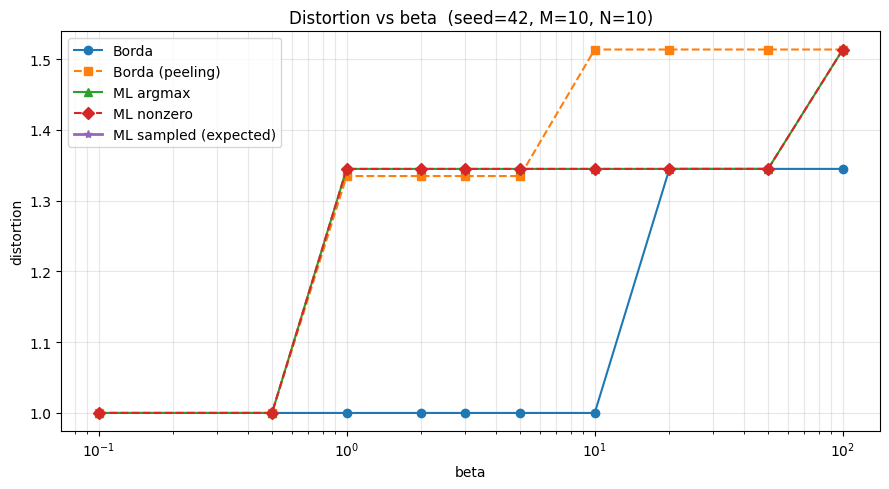

In [7]:
style = {
    'borda':         dict(marker='o', linestyle='-',  label='Borda'),
    'borda_peeling': dict(marker='s', linestyle='--', label='Borda (peeling)'),
    'ml_argmax':     dict(marker='^', linestyle='-',  label='ML argmax'),
    'ml_nonzero':    dict(marker='D', linestyle='--', label='ML nonzero'),
    'ml_sampled':    dict(marker='*', linestyle='-',  label='ML sampled (expected)', linewidth=2),
}

fig, ax = plt.subplots(figsize=(9, 5))
for m, kw in style.items():
    ax.plot(betas, distortions[m], **kw)

ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title(f'Distortion vs beta  (seed=42, M={M}, N={N})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Averaged distortions over 200 random populations

Compute mean and std of each method's distortion across i.i.d. populations drawn from N(0,1).

In [8]:
def compute_distortions_all(utilities, voter_dist, betas, cand_dist=None):
    V, C = utilities.shape
    avg_utils = voter_dist @ utilities
    true_rank = np.argsort(-avg_utils)
    if cand_dist is None:
        cand_dist = np.ones(C, dtype=float) / C

    out = {m: [] for m in methods}
    for b in betas:
        P_b = win_rate_matrix(utilities, voter_dist, beta=b)

        out['borda'].append(
            leaderboard_dist(borda_from_P(P_b, cand_dist), true_rank, avg_utils)[0])
        out['borda_peeling'].append(
            leaderboard_dist(borda_peeling_from_P(P_b, cand_dist), true_rank, avg_utils)[0])

        for key, fn in [('ml_argmax', argmax_lottery_from_population_utilities),
                        ('ml_nonzero', nonzero_max_from_population_utilities)]:
            try:
                _, r = fn(utilities, voter_dist=voter_dist, beta=b)
                out[key].append(leaderboard_dist(r, true_rank, avg_utils)[0])
            except RuntimeError:
                out[key].append(float('nan'))

        try:
            ed, _ = ml_sampled_winner_expected_distortion(utilities, voter_dist, avg_utils, beta=b)
            out['ml_sampled'].append(ed)
        except RuntimeError:
            out['ml_sampled'].append(float('nan'))

    return out


n_populations = 200
M_bulk = 10
N_bulk = 10
betas_bulk = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0]
cand_dist_bulk = np.ones(M_bulk, dtype=float) / M_bulk

rng_bulk = np.random.default_rng(0)
all_distortions = {m: [] for m in methods}

for pop_idx in range(n_populations):
    utils = rng_bulk.standard_normal((N_bulk, M_bulk))
    vdist = np.ones(N_bulk, dtype=float) / N_bulk
    d = compute_distortions_all(utils, vdist, betas_bulk, cand_dist=cand_dist_bulk)
    for m in methods:
        all_distortions[m].append(d[m])

mean_dist = {m: np.nanmean(all_distortions[m], axis=0) for m in methods}
std_dist  = {m: np.nanstd(all_distortions[m],  axis=0) for m in methods}

print(f"Averaged over {n_populations} populations (M={M_bulk}, N={N_bulk})")
for m in methods:
    print(f"  {m}: mean range [{mean_dist[m].min():.4f}, {mean_dist[m].max():.4f}]")

Averaged over 200 populations (M=10, N=10)
  borda: mean range [1.0000, 2.2784]
  borda_peeling: mean range [1.0001, 2.2069]
  ml_argmax: mean range [1.0001, 24.8093]
  ml_nonzero: mean range [1.0001, 26.7536]
  ml_sampled: mean range [nan, nan]


/tmp/ipykernel_2525846/1770605916.py:50: RuntimeWarning: Mean of empty slice
  mean_dist = {m: np.nanmean(all_distortions[m], axis=0) for m in methods}
/home/jennifer/miniconda3/envs/ld/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


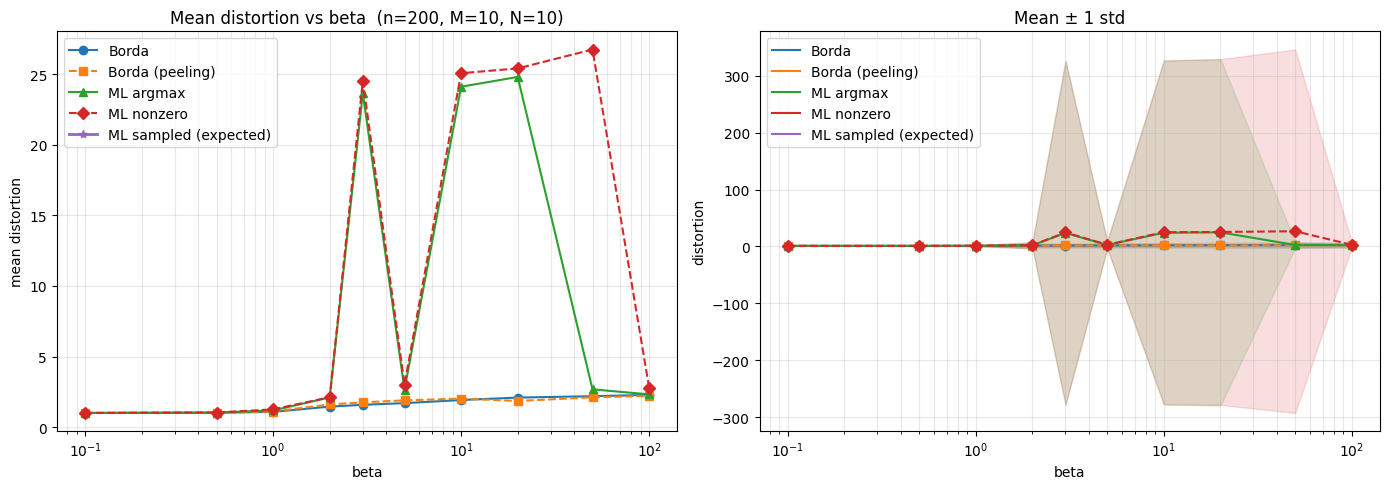

In [9]:
colors = {
    'borda':         'C0',
    'borda_peeling': 'C1',
    'ml_argmax':     'C2',
    'ml_nonzero':    'C3',
    'ml_sampled':    'C4',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for m, kw in style.items():
    ax.plot(betas_bulk, mean_dist[m], color=colors[m], **kw)
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('mean distortion')
ax.set_title(f'Mean distortion vs beta  (n={n_populations}, M={M_bulk}, N={N_bulk})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for m, kw in style.items():
    c = colors[m]
    ax.plot(betas_bulk, mean_dist[m], color=c, **kw)
    ax.fill_between(
        betas_bulk,
        mean_dist[m] - std_dist[m],
        mean_dist[m] + std_dist[m],
        alpha=0.15, color=c,
    )
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title('Mean ± 1 std')
ax.legend(handles=[
    plt.Line2D([0], [0], color=colors[m], label=style[m]['label'])
    for m in methods
])
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## ML methods comparison: sampled winner vs argmax peeling vs nonzero peeling

Isolate the three maximal-lottery-based methods to directly compare their distortions.
Positive difference means the lottery-sampled method has **higher** (worse) distortion.

/tmp/ipykernel_2525846/3307651070.py:34: RuntimeWarning: Mean of empty slice
  mean_diff = np.nanmean(diff, axis=0)


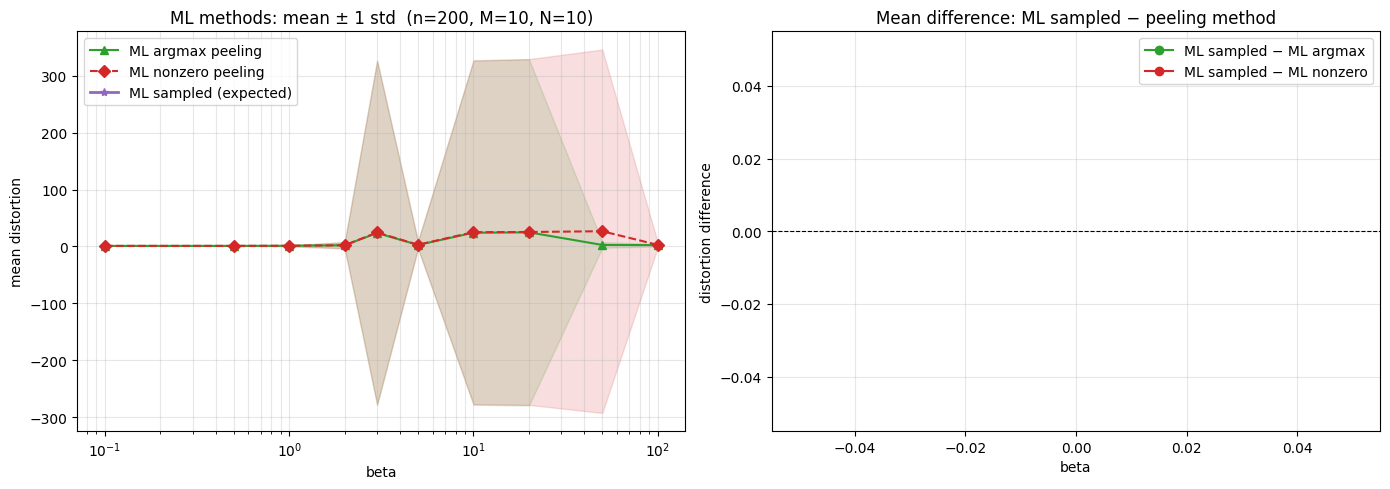

In [11]:
ml_methods = ['ml_argmax', 'ml_nonzero', 'ml_sampled']
ml_style = {
    'ml_argmax':  dict(marker='^', linestyle='-',  label='ML argmax peeling',  color='C2'),
    'ml_nonzero': dict(marker='D', linestyle='--', label='ML nonzero peeling', color='C3'),
    'ml_sampled': dict(marker='*', linestyle='-',  label='ML sampled (expected)', color='C4', linewidth=2),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: mean distortion for all three ML methods
ax = axes[0]
for m in ml_methods:
    ax.plot(betas_bulk, mean_dist[m], **ml_style[m])
    ax.fill_between(
        betas_bulk,
        mean_dist[m] - std_dist[m],
        mean_dist[m] + std_dist[m],
        alpha=0.15, color=ml_style[m]['color'],
    )
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('mean distortion')
ax.set_title(f'ML methods: mean ± 1 std  (n={n_populations}, M={M_bulk}, N={N_bulk})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# right: mean difference ml_sampled - {argmax, nonzero} across populations
ax = axes[1]
for m, color, label in [
    ('ml_argmax',  'C2', 'ML sampled − ML argmax'),
    ('ml_nonzero', 'C3', 'ML sampled − ML nonzero'),
]:
    diff = np.array(all_distortions['ml_sampled']) - np.array(all_distortions[m])
    mean_diff = np.nanmean(diff, axis=0)
    std_diff  = np.nanstd(diff,  axis=0)
    ax.plot(betas_bulk, mean_diff, marker='o', linestyle='-', color=color, label=label)
    ax.fill_between(betas_bulk, mean_diff - std_diff, mean_diff + std_diff,
                    alpha=0.15, color=color)

ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
# ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion difference')
ax.set_title('Mean difference: ML sampled − peeling method')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Fraction of populations where ml_sampled has lower distortion than each peeling method
print(f"{'beta':>8}  {'sampled < argmax':>18}  {'sampled < nonzero':>19}")
print("-" * 52)
for b_idx, b in enumerate(betas_bulk):
    frac_argmax  = np.nanmean(
        np.array(all_distortions['ml_sampled'])[:, b_idx]
        < np.array(all_distortions['ml_argmax'])[:, b_idx]
    )
    frac_nonzero = np.nanmean(
        np.array(all_distortions['ml_sampled'])[:, b_idx]
        < np.array(all_distortions['ml_nonzero'])[:, b_idx]
    )
    print(f"{b:>8.1f}  {frac_argmax:>18.3f}  {frac_nonzero:>19.3f}")

    beta    sampled < argmax    sampled < nonzero
----------------------------------------------------
     0.1               0.000                0.000
     0.5               0.000                0.000
     1.0               0.000                0.000
     2.0               0.000                0.000
     3.0               0.000                0.000
     5.0               0.000                0.000
    10.0               0.000                0.000
    20.0               0.000                0.000
    50.0               0.000                0.000
   100.0               0.000                0.000


## ML sampled-winner peeling

At each round: compute the maximal lottery over remaining candidates, sample a winner from that distribution, remove them, and repeat. Expected distortion is estimated via Monte Carlo over many sampled rankings.

In [13]:
def ml_peeling_sampled_ranking(utilities, voter_dist, beta, rng, tie_tol=1e-12):
    """Sample one ranking from the ML sampled-winner peeling process."""
    C = utilities.shape[1]
    remaining = list(range(C))
    ranking = []
    while remaining:
        rem_utils = utilities[:, remaining]
        try:
            lottery, _ = maximal_lotteries_from_population_utilities(
                rem_utils, voter_dist=voter_dist, beta=beta, tie_tol=tie_tol,
            )
        except RuntimeError:
            # fall back to uniform if LP fails
            lottery = np.ones(len(remaining)) / len(remaining)
        winner_local = rng.choice(len(remaining), p=lottery)
        ranking.append(remaining[winner_local])
        remaining.pop(winner_local)
    return np.array(ranking, dtype=int)


def ml_peeling_sampled_expected_distortion(
    utilities, voter_dist, avg_utils, true_ranking, beta, n_samples=200, seed=None,
):
    """
    Monte Carlo estimate of E[leaderboard_dist] under ML sampled-winner peeling.

    Returns:
        mean_dist: float
        std_dist:  float
        all_dists: array (n_samples,)
    """
    rng = np.random.default_rng(seed)
    all_dists = []
    for _ in range(n_samples):
        ranking = ml_peeling_sampled_ranking(utilities, voter_dist, beta, rng)
        d, _ = leaderboard_dist(ranking, true_ranking, avg_utils)
        all_dists.append(d)
    all_dists = np.array(all_dists)
    return float(all_dists.mean()), float(all_dists.std()), all_dists

In [14]:
# Single population (seed 42), n_samples=200 Monte Carlo draws per beta
n_mc = 200
ml_peeling_sampled_dists = []

for b in betas:
    mean_d, std_d, _ = ml_peeling_sampled_expected_distortion(
        utilities, voter_dist, avg_utilities, true_ranking, beta=b, n_samples=n_mc, seed=0,
    )
    ml_peeling_sampled_dists.append(mean_d)
    print(f"beta={b:6.1f}  mean_dist={mean_d:.4f}  std={std_d:.4f}")

ml_peeling_sampled_dists = np.array(ml_peeling_sampled_dists)

beta=   0.1  mean_dist=1.0000  std=0.0000
beta=   0.5  mean_dist=1.0000  std=0.0000
beta=   1.0  mean_dist=1.3448  std=0.0000
beta=   2.0  mean_dist=1.4227  std=0.2536
beta=   3.0  mean_dist=1.4122  std=0.0826
beta=   5.0  mean_dist=1.4579  std=0.3036
beta=  10.0  mean_dist=1.5562  std=0.5531
beta=  20.0  mean_dist=1.5091  std=0.4485
beta=  50.0  mean_dist=1.4266  std=0.0843
beta= 100.0  mean_dist=1.5134  std=0.0000


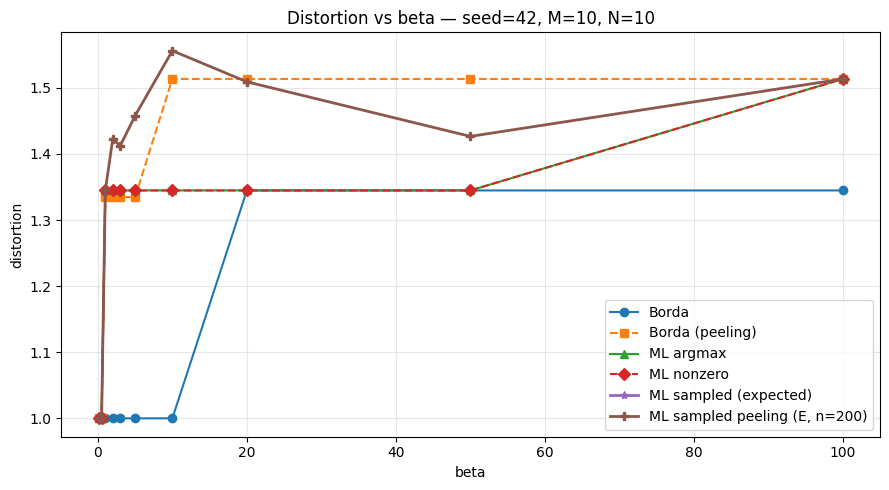

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
for m, kw in style.items():
    ax.plot(betas, distortions[m], **kw)
ax.plot(betas, ml_peeling_sampled_dists,
        marker='P', linestyle='-', color='C5', linewidth=2,
        label=f'ML sampled peeling (E, n={n_mc})')

# ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title(f'Distortion vs beta — seed=42, M={M}, N={N}')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Averaged over n_populations populations; n_mc_bulk MC draws per (population, beta)
n_mc_bulk = 50  # fewer samples per pop to keep runtime manageable

rng_bulk2 = np.random.default_rng(0)
ml_ps_all = []  # shape: (n_populations, len(betas_bulk))

for pop_idx in range(n_populations):
    utils = rng_bulk2.standard_normal((N_bulk, M_bulk))
    vdist = np.ones(N_bulk, dtype=float) / N_bulk
    avg_utils = vdist @ utils
    true_rank = np.argsort(-avg_utils)

    pop_dists = []
    for b in betas_bulk:
        mean_d, _, _ = ml_peeling_sampled_expected_distortion(
            utils, vdist, avg_utils, true_rank, beta=b, n_samples=n_mc_bulk, seed=pop_idx,
        )
        pop_dists.append(mean_d)
    ml_ps_all.append(pop_dists)

    if (pop_idx + 1) % 50 == 0:
        print(f"  {pop_idx + 1}/{n_populations} done")

ml_ps_all = np.array(ml_ps_all)
ml_ps_mean = ml_ps_all.mean(axis=0)
ml_ps_std  = ml_ps_all.std(axis=0)

print("ML sampled peeling mean distortions:", np.round(ml_ps_mean, 4))

ValueError: Probabilities are not non-negative

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for m, kw in style.items():
    ax.plot(betas_bulk, mean_dist[m], color=colors[m], **kw)
ax.plot(betas_bulk, ml_ps_mean,
        marker='P', linestyle='-', color='C5', linewidth=2,
        label=f'ML sampled peeling (E, n={n_mc_bulk})')
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('mean distortion')
ax.set_title(f'Mean distortion vs beta  (n={n_populations}, M={M_bulk}, N={N_bulk})')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for m, kw in style.items():
    c = colors[m]
    ax.plot(betas_bulk, mean_dist[m], color=c, **kw)
    ax.fill_between(betas_bulk,
                    mean_dist[m] - std_dist[m],
                    mean_dist[m] + std_dist[m],
                    alpha=0.15, color=c)
ax.plot(betas_bulk, ml_ps_mean,
        marker='P', linestyle='-', color='C5', linewidth=2,
        label=f'ML sampled peeling (E, n={n_mc_bulk})')
ax.fill_between(betas_bulk, ml_ps_mean - ml_ps_std, ml_ps_mean + ml_ps_std,
                alpha=0.15, color='C5')
# ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title('Mean ± 1 std')
ax.legend(handles=[
    plt.Line2D([0], [0], color=colors[m], label=style[m]['label']) for m in methods
] + [plt.Line2D([0], [0], color='C5', label=f'ML sampled peeling (E, n={n_mc_bulk})')],
fontsize=8)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## Computing the distribution over rankings

In [35]:
def ranking_distribution_pruned(candidates, maximal_lottery_fn):
    cache = {}

    def get_lottery(S):
        S = frozenset(S)
        if S not in cache:
            cache[S] = maximal_lottery_fn(list(S))
        return cache[S]

    def recurse(remaining):
        remaining = frozenset(remaining)

        if len(remaining) == 1:
            c = next(iter(remaining))
            return {(c,): 1.0}

        ml = get_lottery(remaining)
        result = {}

        for c, p in ml.items():
            if p == 0:
                continue

            subdist = recurse(remaining - {c})

            for suffix, q in subdist.items():
                result[(c,) + suffix] = p * q

        return result

    return recurse(frozenset(candidates))

In [44]:
from utils_3 import PairwiseData, Population
from datasets import load_dataset

ds = load_dataset("lmarena-ai/arena-human-preference-140k")
ds = dict(ds)

pw = PairwiseData(ds, M=30, N=30)
population = Population(pw)

100%|██████████| 30/30 [00:00<00:00, 30.87it/s]


In [45]:
import numpy as np

In [46]:
real_avg_utils = population.avg_utilities
real_true_rank = np.argsort(-real_avg_utils)
candidate_labels = [pw.idx_to_candidates[i] for i in range(pw.M)]

print("Candidates (true ranking order):")
for rank, idx in enumerate(real_true_rank):
    print(f"  {rank+1:2d}. {candidate_labels[idx]}  (avg_util={real_avg_utils[idx]:.4f})")

Candidates (true ranking order):
   1. gemini-2.5-pro  (avg_util=2.0536)
   2. o3-2025-04-16  (avg_util=1.7623)
   3. chatgpt-4o-latest-20250326  (avg_util=1.7442)
   4. grok-3-preview-02-24  (avg_util=1.7247)
   5. deepseek-r1-0528  (avg_util=1.6786)
   6. llama-4-maverick-03-26-experimental  (avg_util=1.6069)
   7. gemini-2.5-flash  (avg_util=1.5916)
   8. qwen3-235b-a22b-no-thinking  (avg_util=1.3759)
   9. gpt-4.1-2025-04-14  (avg_util=1.3261)
  10. deepseek-v3-0324  (avg_util=1.3094)
  11. mistral-medium-2505  (avg_util=1.2846)
  12. o4-mini-2025-04-16  (avg_util=1.2651)
  13. minimax-m1  (avg_util=1.2000)
  14. claude-opus-4-20250514  (avg_util=1.1780)
  15. claude-opus-4-20250514-thinking-16k  (avg_util=1.1400)
  16. grok-3-mini-beta  (avg_util=1.1354)
  17. gemma-3-27b-it  (avg_util=1.1222)
  18. claude-sonnet-4-20250514-thinking-32k  (avg_util=1.0140)
  19. gpt-4.1-mini-2025-04-14  (avg_util=0.9997)
  20. gemini-2.0-flash-001  (avg_util=0.9486)
  21. qwen3-30b-a3b  (avg_util=0

In [53]:
beta = 10.0
top_k = 30  # K! permutations and 2^K subsets — keep K <= 8 for tractability

top_k_indices = real_true_rank[:top_k].tolist()

def make_maximal_lottery_fn(utilities, voter_dist, beta=1.0):
    """Returns a maximal_lottery_fn(candidates) -> dict[candidate -> prob]."""
    def fn(candidates):
        sub_utils = utilities[:, candidates]
        lottery, _ = maximal_lotteries_from_population_utilities(
            sub_utils, voter_dist=voter_dist, beta=beta,
        )
        return {c: float(lottery[i]) for i, c in enumerate(candidates)}
    return fn

ml_fn = make_maximal_lottery_fn(
    population.population_utilities, population.voter_distr, beta=beta
)

In [54]:
dist = ranking_distribution_pruned(top_k_indices, ml_fn)

sorted_dist = sorted(dist.items(), key=lambda x: -x[1])
total_mass = sum(dist.values())

print(f"Ranking distribution over top-{top_k} candidates (beta={beta})")
print(f"Total probability mass: {total_mass:.6f}")
print()
for ranking, prob in sorted_dist[:20]:
    names = " > ".join(candidate_labels[c] for c in ranking)
    print(f"  {prob:.4f}  {names}")

Ranking distribution over top-30 candidates (beta=10.0)
Total probability mass: 1.000000

  0.6737  gemini-2.5-pro > grok-3-preview-02-24 > chatgpt-4o-latest-20250326 > o3-2025-04-16 > deepseek-r1-0528 > gemini-2.5-flash > llama-4-maverick-03-26-experimental > gpt-4.1-2025-04-14 > qwen3-235b-a22b-no-thinking > mistral-medium-2505 > deepseek-v3-0324 > o4-mini-2025-04-16 > claude-opus-4-20250514 > gemma-3-27b-it > minimax-m1 > claude-opus-4-20250514-thinking-16k > grok-3-mini-beta > gpt-4.1-mini-2025-04-14 > gemini-2.0-flash-001 > claude-sonnet-4-20250514-thinking-32k > qwen3-30b-a3b > claude-sonnet-4-20250514 > o3-mini > command-a-03-2025 > claude-3-7-sonnet-20250219-thinking-32k > llama-4-maverick-17b-128e-instruct > claude-3-5-sonnet-20241022 > claude-3-7-sonnet-20250219 > amazon.nova-pro-v1:0 > claude-3-5-haiku-20241022
  0.2718  gemini-2.5-pro > grok-3-preview-02-24 > chatgpt-4o-latest-20250326 > o3-2025-04-16 > deepseek-r1-0528 > gemini-2.5-flash > llama-4-maverick-03-26-experiment

## Checking rankings

In [ ]:
from utils_3 import PairwiseData, Population
from datasets import load_dataset

ds = load_dataset("lmarena-ai/arena-human-preference-140k")
ds = dict(ds)

pw = PairwiseData(ds, M=30, N=30)
population = Population(pw)

100%|██████████| 30/30 [00:00<00:00, 30.92it/s]


In [ ]:
empirical_candidate_distr = np.zeros(pw.M)

winners = pw.winners
losers = pw.losers

for i in range(len(winners)):
    empirical_candidate_distr[losers[i]] += 1.0
    empirical_candidate_distr[winners[i]] += 1.0

empirical_candidate_distr = empirical_candidate_distr / empirical_candidate_distr.sum()

In [ ]:
lottery, _ = maximal_lotteries_from_population_utilities(
    population.population_utilities, voter_dist=population.voter_distr, beta=beta,
)

print(f"Maximal lottery over all {pw.M} candidates (beta={beta}):")
for i in np.argsort(-lottery):
    if lottery[i] > 0:
        print(f"  {lottery[i]:.4f}  {candidate_labels[i]}")

Maximal lottery over all 30 candidates (beta=1.0):
  1.0000  gemini-2.5-pro


In [ ]:
rng_peel = np.random.default_rng(0)
remaining = list(range(pw.M))
leaderboard = []
candidate_labels = [pw.idx_to_candidates[i] for i in range(pw.M)]

round_num = 1
while remaining:
    sub_utils = population.population_utilities[:, remaining]
    sub_lottery, _ = maximal_lotteries_from_population_utilities(
        sub_utils, voter_dist=population.voter_distr, beta=beta,
    )

    print(f"Round {round_num}  ({len(remaining)} candidates remaining)")
    for local_i in np.argsort(-sub_lottery):
        if sub_lottery[local_i] > 0:
            print(f"    {sub_lottery[local_i]:.4f}  {candidate_labels[remaining[local_i]]}")

    winner_local = rng_peel.choice(len(remaining), p=sub_lottery)
    winner = remaining[winner_local]
    leaderboard.append(winner)
    remaining.pop(winner_local)
    print(f"  => sampled winner: {candidate_labels[winner]}\n")
    round_num += 1

print("Final leaderboard:")
for rank, idx in enumerate(leaderboard):
    print(f"  {rank+1:2d}. {candidate_labels[idx]}")

Round 1  (30 candidates remaining)
    1.0000  gemini-2.5-pro
  => sampled winner: gemini-2.5-pro

Round 2  (29 candidates remaining)
    1.0000  o3-2025-04-16
  => sampled winner: o3-2025-04-16

Round 3  (28 candidates remaining)
    1.0000  chatgpt-4o-latest-20250326
  => sampled winner: chatgpt-4o-latest-20250326

Round 4  (27 candidates remaining)
    1.0000  grok-3-preview-02-24
  => sampled winner: grok-3-preview-02-24

Round 5  (26 candidates remaining)
    1.0000  deepseek-r1-0528
  => sampled winner: deepseek-r1-0528

Round 6  (25 candidates remaining)
    1.0000  llama-4-maverick-03-26-experimental
  => sampled winner: llama-4-maverick-03-26-experimental

Round 7  (24 candidates remaining)
    1.0000  gemini-2.5-flash
  => sampled winner: gemini-2.5-flash

Round 8  (23 candidates remaining)
    1.0000  qwen3-235b-a22b-no-thinking
  => sampled winner: qwen3-235b-a22b-no-thinking

Round 9  (22 candidates remaining)
    1.0000  gpt-4.1-2025-04-14
  => sampled winner: gpt-4.1-202

It's entirely deterministic.

In [ ]:
sub_lottery

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## With marginal win-rates from the data

In [ ]:
winners = pw.winners
losers = pw.losers

ij_wins = np.zeros((pw.M, pw.M))
for w, l in zip(winners, losers):
    ij_wins[w, l] += 1

total = ij_wins + ij_wins.T
# marginal win-rate: (wins_ij - wins_ji) / (wins_ij + wins_ji); 0 where undefined
with np.errstate(invalid="ignore", divide="ignore"):
    margin_wins = np.where(total > 0, (ij_wins - ij_wins.T) / total, 0.0)

np.fill_diagonal(margin_wins, 0.0)
print("margin_wins shape:", margin_wins.shape)
print("undefined pairs set to 0:", (total == 0).sum())

NameError: name 'pw' is not defined

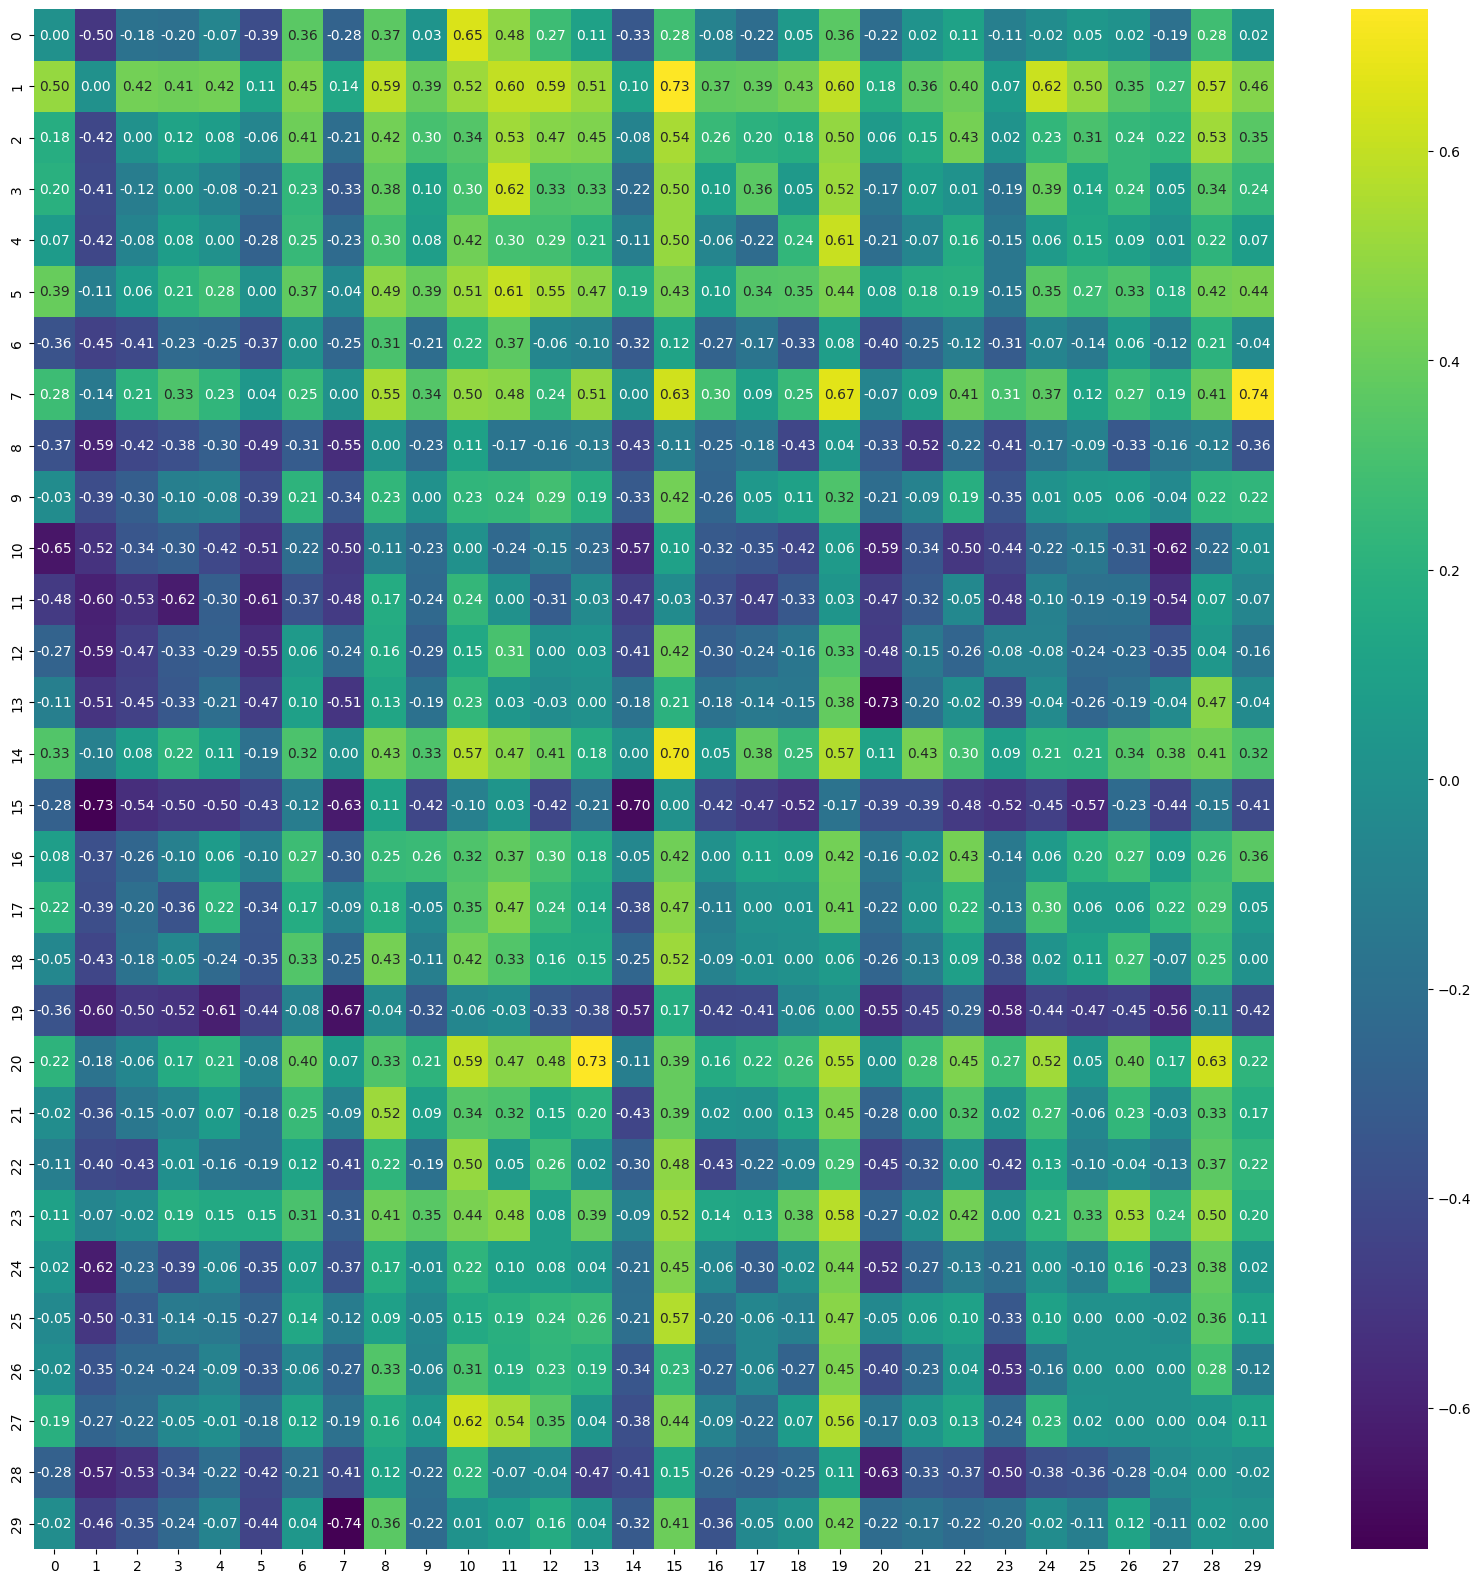

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
sns.heatmap(
    margin_wins,
    annot=True,      # show numbers in cells
    fmt=".2f",       # number format
    cmap="viridis"
)
plt.show()

In [ ]:
print(beta)

1.0


In [ ]:
from utils_3 import _pairwise_win_probabilities_from_population_utilities

P = _pairwise_win_probabilities_from_population_utilities(
        population.population_utilities,
        voter_dist=population.voter_distr,
        beta=beta,
    )
    # margins = 

actual_margin_win_rates = P - P.T

In [ ]:
population.population_utilities.max()

np.float64(3.7830695486536143)

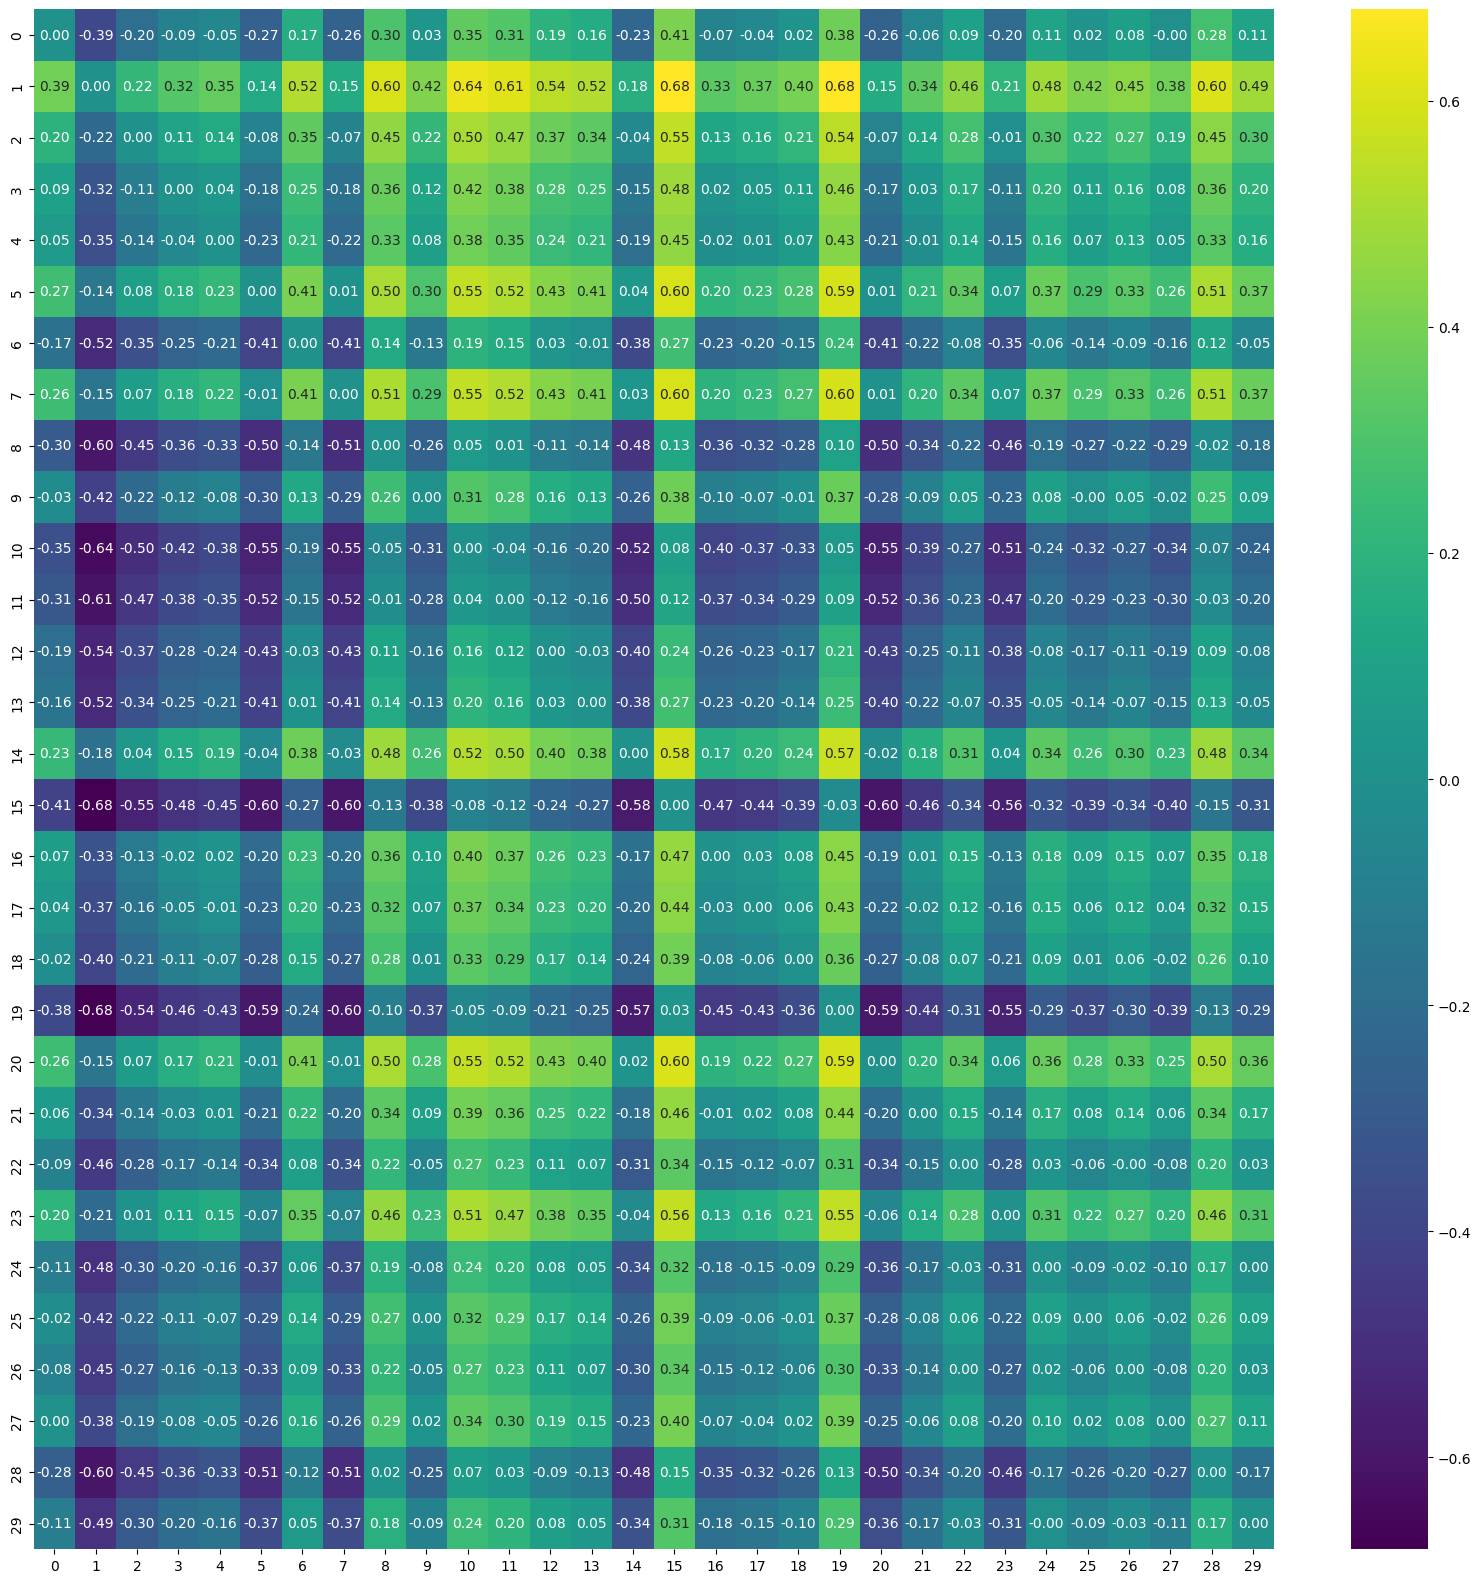

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    actual_margin_win_rates,
    annot=True,      # show numbers in cells
    fmt=".2f",       # number format
    cmap="viridis"
)
plt.show()

In [ ]:
from scipy.optimize import linprog


def maximal_lotteries_from_win_rates(margins, tie_tol=1e-12):
    C = margins.shape[0]
    result = linprog(
        c=np.zeros(C, dtype=float),
        A_ub=-margins.T,
        b_ub=np.zeros(C, dtype=float),
        A_eq=np.ones((1, C), dtype=float),
        b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * C,
        method="highs",
    )
    if not result.success:
        raise RuntimeError(f"Maximal lottery solve failed: {result.message}")
    lottery = np.asarray(result.x, dtype=float)
    lottery[np.abs(lottery) < tie_tol] = 0.0
    lottery /= lottery.sum()
    ranking = np.argsort(-lottery)
    return lottery, ranking

In [ ]:
def argmax_lottery_from_wins(margins, tie_tol=1e-12):
    """
    Peeling ranking via maximal lotteries (argmax variant).

    Each round: compute maximal lottery on remaining candidates,
    select the candidate with the highest lottery mass, remove and repeat.
    """
    C = margins.shape[0]
    remaining = list(range(C))
    ranking = []
    round_lotteries = []

    while remaining:
        rem_idx = np.asarray(remaining, dtype=int)
        rem_margins = margins[np.ix_(rem_idx, rem_idx)]
        lottery, _ = maximal_lotteries_from_win_rates(rem_margins, tie_tol=tie_tol)
        round_lotteries.append(lottery.copy())

        winner_local = int(np.argmax(lottery))
        winner_global = remaining[winner_local]
        ranking.append(winner_global)
        remaining.pop(winner_local)

    return round_lotteries, np.array(ranking, dtype=int)

In [ ]:
round_lotteries_argmax, ranking_argmax = argmax_lottery_from_wins(margins=margin_wins)
print("argmax ranking:", ranking_argmax)
for i, lot in enumerate(round_lotteries_argmax):
    print(f"round {i}: {lot}")

argmax ranking: [ 1  7  5 14  2 20 21 23  4  3 16  9 17 27  0 18 25 22 24 29  6 26 12 13
 11 28  8 10 19 15]
round 0: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
round 1: [0.         0.         0.         0.         0.36085982 0.
 0.42172774 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.21741244 0.         0.         0.         0.
 0.         0.         0.         0.         0.        ]
round 2: [0.         0.         0.         0.         0.53109133 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.30196102 0.         0.         0.16694766 0.         0.
 0.         0.         0.         0.        ]
round 3: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
round 4: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
round 5: [0. 

In [ ]:
def nonzero_max_from_wins(margins, tie_tol=1e-12):
    """
    Peeling ranking via maximal lotteries (nonzero variant).

    Each round: compute maximal lottery on remaining candidates,
    append all candidates with nonzero mass (ordered by decreasing probability),
    remove them and repeat.
    """
    C = margins.shape[0]
    remaining = list(range(C))
    ranking = []
    round_lotteries = []

    while remaining:
        rem_idx = np.asarray(remaining, dtype=int)
        rem_margins = margins[np.ix_(rem_idx, rem_idx)]
        lottery, ranking_local = maximal_lotteries_from_win_rates(rem_margins, tie_tol=tie_tol)
        round_lotteries.append(lottery.copy())

        nonzero_local = ranking_local[lottery[ranking_local] > tie_tol]
        if nonzero_local.size == 0:
            nonzero_local = np.array([int(np.argmax(lottery))], dtype=int)

        selected_globals = [remaining[i] for i in nonzero_local]
        ranking.extend(selected_globals)

        selected_set = set(selected_globals)
        remaining = [c for c in remaining if c not in selected_set]

    return round_lotteries, np.array(ranking, dtype=int)

In [ ]:
round_lotteries_nonzero, ranking_nonzero = nonzero_max_from_wins(margins=margin_wins)
print("nonzero ranking:", ranking_nonzero)
for i, lot in enumerate(round_lotteries_nonzero):
    print(f"round {i}: {lot}")

nonzero ranking: [ 1  7  5 20 14  2 21 23  3 16  9 17  4 27 26  0 24 25 18 29 22 12 13  6
 11 19 15 28  8 10]
round 0: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
round 1: [0.         0.         0.         0.         0.36085982 0.
 0.42172774 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.21741244 0.         0.         0.         0.
 0.         0.         0.         0.         0.        ]
round 2: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
round 3: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
round 4: [0.         0.07055666 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.67692477 0.         0.25251857
 0.         0.         0.         0.         0.         0.        ]
round 5: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0

In [ ]:
from utils_3 import leaderboard_dist

true_ranking = np.argsort(-population.avg_utilities)

dist_argmax, _ = leaderboard_dist(ranking_argmax, true_ranking, population.avg_utilities)
dist_nonzero, _ = leaderboard_dist(ranking_nonzero, true_ranking, population.avg_utilities)
print(f"ML argmax  distortion: {dist_argmax:.6f}")
print(f"ML nonzero distortion: {dist_nonzero:.6f}")

ML argmax  distortion: 1.025071
ML nonzero distortion: 1.025071


In [ ]:
round_lotteries_argmax, ranking_argmax = argmax_lottery_from_wins(margins=actual_margin_win_rates)
print("argmax ranking:", ranking_argmax)
for i, lot in enumerate(round_lotteries_argmax):
    print(f"round {i}: {lot}")

argmax ranking: [ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]
round 0: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
round 1: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
round 2: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
round 3: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
round 4: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
round 5: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0.]
round 6: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
round 7: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
round 8: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
round 9: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
round 10: 